# Assignment 2 - AI: Deep Learning

In [325]:
# imports

import pandas as pd
import torch
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn

In [326]:
# Load and visualize data
training_data = pd.read_csv("data/g2p_train.csv")
training_data = training_data.dropna()
print(training_data.head())

        word                  phonemes
0      vigil            V IH1 JH AH0 L
1  ethelinda  EH0 TH EH0 L IY1 N D AH0
2      yaney               Y EY1 N IY0
3   caniglia   K AH0 N IH1 G L IY0 AH0
4     sondra           S AA1 N D R AH0


In [327]:
special_chars = ["<PAD>", "<SOS>", "<EOS>", "<UNKS>"]
char_vocab = {}

for id, char in enumerate(special_chars):
    char_vocab[char] = id
    
current_id = len(char_vocab)
for word in training_data["word"]:
    for char in word:
        if char in char_vocab:
            continue
        else:
            char_vocab[char] = current_id
            current_id += 1
            
print(char_vocab)


{'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNKS>': 3, 'v': 4, 'i': 5, 'g': 6, 'l': 7, 'e': 8, 't': 9, 'h': 10, 'n': 11, 'd': 12, 'a': 13, 'y': 14, 'c': 15, 's': 16, 'o': 17, 'r': 18, 'u': 19, 'j': 20, 'k': 21, 'q': 22, 'p': 23, 'm': 24, 'b': 25, 'z': 26, 'f': 27, 'w': 28, 'x': 29}


In [328]:
# Build phoneme vocabulary
phoneme_vocab = {}
special_chars = ["<PAD>", "<SOS>", "<EOS>", "<UNKS>"]

for id, phoneme in enumerate(special_chars):
    phoneme_vocab[phoneme] = id

current_id = len(phoneme_vocab)
for phonemes in training_data["phonemes"]:
    phonemes = phonemes.split()
    for phoneme in phonemes:
        if phoneme in phoneme_vocab:
            continue
        else:
            phoneme_vocab[phoneme] = current_id
            current_id += 1
            
print(phoneme_vocab)
        

{'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNKS>': 3, 'V': 4, 'IH1': 5, 'JH': 6, 'AH0': 7, 'L': 8, 'EH0': 9, 'TH': 10, 'IY1': 11, 'N': 12, 'D': 13, 'Y': 14, 'EY1': 15, 'IY0': 16, 'K': 17, 'G': 18, 'S': 19, 'AA1': 20, 'R': 21, 'HH': 22, 'SH': 23, 'ER0': 24, 'T': 25, 'UW1': 26, 'AY1': 27, 'AE1': 28, 'NG': 29, 'W': 30, 'OW2': 31, 'P': 32, 'EH1': 33, 'AE2': 34, 'OW0': 35, 'M': 36, 'IH0': 37, 'Z': 38, 'CH': 39, 'B': 40, 'EH2': 41, 'OW1': 42, 'IY2': 43, 'AY2': 44, 'AA2': 45, 'F': 46, 'AO1': 47, 'AA0': 48, 'UW2': 49, 'ER1': 50, 'AO0': 51, 'AW0': 52, 'AH1': 53, 'IH2': 54, 'AY0': 55, 'AE0': 56, 'AH2': 57, 'ZH': 58, 'UH1': 59, 'EY0': 60, 'AO2': 61, 'AW2': 62, 'DH': 63, 'UW0': 64, 'OY1': 65, 'EY2': 66, 'AW1': 67, 'ER2': 68, 'UH2': 69, 'UH0': 70, 'OY2': 71, 'OY0': 72}


In [329]:
class WPPToIntegerSequence(Dataset):
    
    def __init__(self, data, char_vocab, phoneme_vocab):
        self.data = data
        self.char_vocab = char_vocab
        self.phoneme_vocab = phoneme_vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        word = row["word"]
        phonemes = row["phonemes"]
        
        word_ids = []
        for char in word:
            if char in char_vocab:
                word_ids.append(char_vocab[char])
            else:
                word_ids.append(char_vocab["<UNK>"])
        
        phoneme_ids = [phoneme_vocab["<SOS>"]]
        for phoneme in phonemes.split():
            if phoneme in phoneme_vocab:
                phoneme_ids.append(phoneme_vocab[phoneme])        
            else:
                phoneme_ids.append(phoneme_vocab["<UNK>"])
        phoneme_ids.append(phoneme_vocab["<EOS>"])
        
        return (
            torch.tensor(word_ids, dtype=torch.long),
            torch.tensor(phoneme_ids, dtype=torch.long)
        )
        

In [330]:
def collate_fn(batch):
    src_batch = []
    tgt_batch = []

    for src, tgt in batch:
        src_batch.append(src)
        tgt_batch.append(tgt)

    src_padded = pad_sequence(
        src_batch,
        batch_first=True,
        padding_value=0
    )

    tgt_padded = pad_sequence(
        tgt_batch,
        batch_first=True,
        padding_value=0
    )

    return src_padded, tgt_padded

In [331]:
train_dataset = WPPToIntegerSequence(training_data, char_vocab, phoneme_vocab)
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)

In [332]:
print("Character vocabulary size:", len(char_vocab))
print("Phoneme vocabulary size:", len(phoneme_vocab))
print("Training set size:", len(training_data))

Character vocabulary size: 30
Phoneme vocabulary size: 73
Training set size: 92424


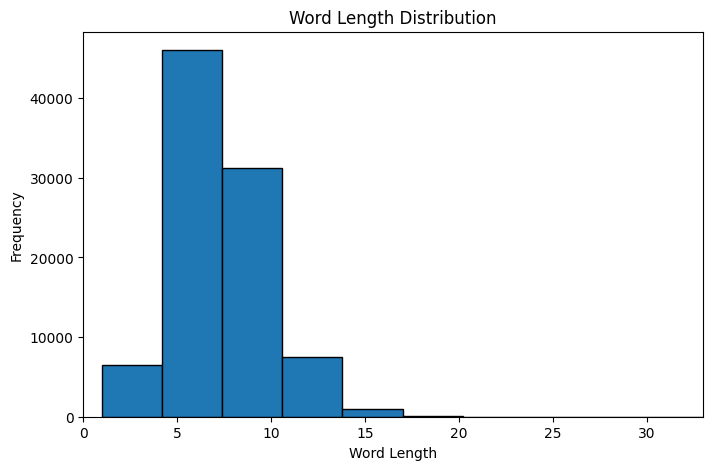

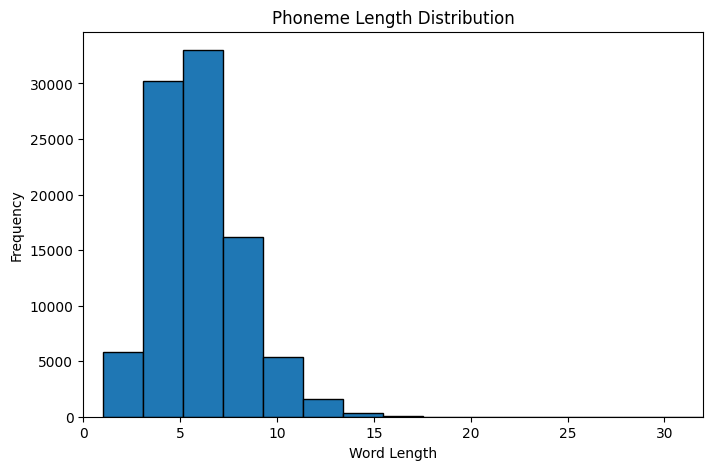

In [333]:
word_lengths = []

for word in training_data["word"]:
    word_lengths.append(len(word))
    
phoneme_lengths = []
for phonemes in training_data["phonemes"]:
    phoneme_lengths.append(len(phonemes.split()))
    
plt.figure(figsize=(8, 5))

plt.hist(word_lengths, bins=10, edgecolor="black")
plt.title("Word Length Distribution")
plt.xlim(0, max(word_lengths))
plt.xlabel("Word Length")
plt.ylabel("Frequency")

plt.show()

plt.figure(figsize=(8, 5))
plt.hist(phoneme_lengths, bins=15, edgecolor="black")
plt.title("Phoneme Length Distribution")
plt.xlim(0, max(phoneme_lengths))
plt.xlabel("Word Length")
plt.ylabel("Frequency")

plt.show()

In [334]:
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W_f = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_i = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_o = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_c = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, h_prev, c_prev):
        combined = torch.cat((x, h_prev), dim=1)

        f = torch.sigmoid(self.W_f(combined))
        i = torch.sigmoid(self.W_i(combined))
        o = torch.sigmoid(self.W_o(combined))
        c_tilde = torch.tanh(self.W_c(combined))

        c = f * c_prev + i * c_tilde
        h = o * torch.tanh(c)

        return h, c

In [335]:
class ContextLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

        combined_size = input_size + 2 * hidden_size

        self.W_f = nn.Linear(combined_size, hidden_size)
        self.W_i = nn.Linear(combined_size, hidden_size)
        self.W_o = nn.Linear(combined_size, hidden_size)
        self.W_c = nn.Linear(combined_size, hidden_size)

    def forward(self, x, h_prev, c_prev, z):
        combined = torch.cat((x, h_prev, z), dim=1)

        f = torch.sigmoid(self.W_f(combined))
        i = torch.sigmoid(self.W_i(combined))
        o = torch.sigmoid(self.W_o(combined))
        c_tilde = torch.tanh(self.W_c(combined))

        c = f * c_prev + i * c_tilde
        h = o * torch.tanh(c)

        return h, c

In [336]:
#Encoder
class Encoder(nn.Module):
    def __init__(self, src_vocab_size: int, embed_dim: int, hidden_size: int, num_layers: int = 1):
        super().__init__()
        self.src_vocab_size = src_vocab_size
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(src_vocab_size, embed_dim)
        self.lstm = LSTMCell(embed_dim, hidden_size)

    def forward(self, src):
        batch, src_len = src.shape
        x = self.embedding(src)
        h = torch.zeros(batch, self.hidden_size)
        c = torch.zeros(batch, self.hidden_size)
        all_h = []
        
        for t in range(src_len):
            h, c = self.lstm(x[:, t], h, c)
            all_h.append(h)
        all_h = torch.stack(all_h)
        
        return all_h, (h.unsqueeze(0), c.unsqueeze(0))
    # src: (batch, src_len)
    # Returns (all_h, (h_n, c_n))
    # all_h: (src_len, batch, hidden_size)
    # h_n, c_n: (num_layers, batch, hidden_sized
    

In [337]:
class Decoder(nn.Module):
    def __init__(self, tgt_vocab_size: int, embed_dim: int, hidden_size: int, num_layers: int = 1, context_mode: str = "none"):
        super().__init__()
        self.tgt_vocab_size = tgt_vocab_size
        self.embedding = nn.Embedding(tgt_vocab_size, embed_dim)
        self.context_mode = context_mode
        self.output_layer = nn.Linear(hidden_size, tgt_vocab_size)
        if context_mode == "none":
            self.lstm = LSTMCell(embed_dim, hidden_size)
        elif context_mode in ["fixed", "attn"]:
            self.lstm = ContextLSTMCell(embed_dim, hidden_size)
        else:
            raise ValueError("invalid context mode")

 
    # context_mode in {"none", "fixed", "attn"}
    def forward(self, tgt, hidden, encoder_outputs=None):
        h_n, c_n = hidden
        all_logits = []
        batch, tgt_len = tgt.shape
        
        h = h_n[0]
        c = c_n[0]
        x  = self.embedding(tgt)
        if self.context_mode == "fixed":
            z = h_n[0]
        for t in range(tgt_len):
            x_t = x[:, t]
            if self.context_mode=="none":
                h,c = self.lstm(x_t, h, c)
                
            elif self.context_mode=="fixed":
                h, c = self.lstm(x_t, h, c, z)
            elif self.context_mode == "attn":
                scores = torch.sum(encoder_outputs * h.unsqueeze(0), dim=2).transpose(0, 1)
                alpha = torch.softmax(scores, dim=1)
                z_t = torch.sum(alpha.transpose(0, 1).unsqueeze(2) * encoder_outputs, dim=0)
                h, c = self.lstm(x_t, h, c, z_t)

            logits = self.output_layer(h)
            all_logits.append(logits)
        
        all_logits = torch.stack(all_logits,1)
        return all_logits, (h.unsqueeze(0), c.unsqueeze(0))
    # tgt: (batch, tgt_len)
    # hidden: (h_0, c_0)
    # h_0, c_0: (num_layers, batch, hidden_size)
    # encoder_outputs: optional (only needed for attention)
    # (src_len, batch, hidden_size)
    #
    # Returns (logits, (h_n, c_n))
    # logits: (batch, tgt_len, tgt_vocab_size)
    # h_n, c_n: (num_layers, batch, hidden_size)

In [338]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing: bool = True):
        enc_outputs, hidden = self.encoder(src)
        dec_input = tgt[:,:-1]
        logits,_ = self.decoder(dec_input, hidden, enc_outputs) 
        return logits
    # Returns logits: (batch, tgt_len-1, tgt_vocab_size)
    def greedy_decode(self, src, max_len: int = 30):
        batch_size = src.shape[0]
        device = src.device

        enc_outputs, hidden = self.encoder(src)

        input_token = torch.full(
            (batch_size, 1),
            1, 
            dtype=torch.long,
            device=device
        )
        predictions = []

        for _ in range(max_len):
            logits, hidden = self.decoder(
                input_token,
                hidden,
                enc_outputs
            )

            next_token = logits[:, -1, :].argmax(dim=-1)

            predictions.append(next_token)

            input_token = next_token.unsqueeze(1)

        predictions = torch.stack(predictions, dim=1)
        return predictions

In [339]:
# Training

num_epochs = 5
training_losses = []
val_losses = []
context_mode = "attn"

encoder = Encoder(len(char_vocab), 128, 256, 1)
decoder = Decoder(len(phoneme_vocab), 128, 256, 1, context_mode)
model = Seq2Seq(encoder, decoder)

loss_fn = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    for src, tgt in train_loader:
        optimizer.zero_grad()
        logits = model(src, tgt)
        target = tgt[:, 1:]
        logits = logits[:, :target.size(1), :]
        loss = loss_fn(logits.reshape(-1, logits.size(-1)), target.reshape(-1))
        loss.backward()
        
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    training_losses.append(avg_train_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | train loss: {avg_train_loss:.4f}")

Epoch 1/5 | train loss: 1.1180


KeyboardInterrupt: 